# Experiments for comparison of Oracles

## Hyperparameters Adjustment
```
time python al.py al.strategy=perf_dal_oracle
time python al.py al.strategy=perf_dal_oracle dataset_name=stl10
time python al.py al.strategy=perf_dal_oracle dataset_name=snacks al.acq_size=20
time python al.py al.strategy=perf_dal_oracle dataset_name=dopanim al.acq_size=50
time python al.py al.strategy=perf_dal_oracle dataset_name=dtd al.acq_size=50

time python al.py al.strategy=cross_domain_oracle al.cdo.tau=20
time python al.py al.strategy=cross_domain_oracle al.cdo.tau=20 dataset_name=stl10
time python al.py al.strategy=cross_domain_oracle al.cdo.tau=20 dataset_name=snacks al.acq_size=20
time python al.py al.strategy=cross_domain_oracle al.cdo.tau=20 dataset_name=dopanim al.acq_size=50
time python al.py al.strategy=cross_domain_oracle al.cdo.tau=20 dataset_name=dtd al.acq_size=50

time python al.py al.strategy=simulated_annealing_oracle al.sas.sa_steps=100
time python al.py al.strategy=simulated_annealing_oracle al.sas.sa_steps=100 dataset_name=stl10
time python al.py al.strategy=simulated_annealing_oracle al.sas.sa_steps=100 dataset_name=snacks al.acq_size=20
time python al.py al.strategy=simulated_annealing_oracle al.sas.sa_steps=100 dataset_name=dtd al.acq_size=50
```

### BoSS
| T   | Cifar-10 | Snacks | Dopanim | DTD    |
| --- | -------- | ------ | ------- | ------ |
| 110 | 10:07    | 13:19  | 30:47   | 22:07  |


### CDO
| m   | Cifar-10 | Snacks | Dopanim | DTD     | 
| --- | -------- | ------ | ------- | ------- | 
| 20  | 10:26    | 28:22  | 2:47:08 | 2:46:14 |
| 10  | -        | 14:11  | -       | -       | 
| 4   | -        | -      | 33:25   | -       | 
| 3   | -        | -      | -       | 24:56   | 

### SAS

| s   | Cifar-10 | STL-10 | Snacks | Dopanim | DTD     |
| --- | -------- | ------ | ------ | ------- | ------- |
| 100 | 4:05     | -      | 5:51   | 14:01   |  14:14  |
| 250 | 10:20    | -      | 14:06  | 36:53   |  -      |
| 225 | -        | -      | 13:24  | -       |  -      |
| 215 | -        | -      | -      | 31:56   |  -      |
| 150 | -        | -      | -      | -       |  22:14  |

In [4]:
!rsync -avz cluster.ies:/mnt/work/dhuseljic/experiments/mlflow/perf_dal /home/dhuseljic/mlflow

import os 
import json
import mlflow
import torch
import matplotlib
import numpy as np
import pylab as plt

from pathlib import Path
from datetime import datetime
from collections import defaultdict

os.makedirs('plots', exist_ok=True)
matplotlib.rcParams['figure.figsize'] = (4, 3)
torch.set_grad_enabled(False)

def filter_by_date(runs, year, month, day, hour=0, min=0, fn=np.greater):
    filtered_runs = []
    for run in runs:
        start_time = datetime.fromtimestamp(run.info.start_time / 1000) # in ms
        filter_time = datetime(year, month, day, hour, min)
        if fn(start_time, filter_time):
            filtered_runs.append(run)
    return filtered_runs

def rename_parameter(run, param_name, name):
    run.data.params[param_name] = name
    return run


def download_artifacts(run, to_path=Path.home() / 'server_artifacts'):
    global_uri = Path(run.info.artifact_uri)
    local_uri = Path(*global_uri.parts[-4:])
    dest = to_path / local_uri
    os.makedirs(dest, exist_ok=True)
    print(f'Downloading artifacts from {global_uri} to {dest}')
    os.system(f'rsync -avz cluster.ies:{global_uri}/ {dest}')
    return dest

def get_runs(uri, exp_name, query_list):
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)
    experiment_id = client.get_experiment_by_name(exp_name).experiment_id
    runs = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
    runs = sorted(runs, key=lambda run: int(run.data.params['random_seed']))
    if len(runs) == 0:
        print(f'No runs found with query list {query_list}.')
    return runs


receiving incremental file list
perf_dal/
perf_dal/oracle.db

sent 166,039 bytes  received 1,265,213 bytes  190,833.60 bytes/sec
total size is 660,254,720  speedup is 461.31


In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler

# Define a custom style dictionary
custom_style = {
    # Figure and axes
    "figure.figsize": (10, 6),
    "figure.dpi": 100,
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    
    # Lines and markers
    "lines.linewidth": 1.5,
    "lines.markersize": 6,

    # Font settings
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],

    # Save figure settings
    "savefig.dpi": 300,
}

# Update matplotlib's global rcParams with your custom style
mpl.rcParams.update(custom_style)
mpl.rcParams['axes.grid'] = True
mpl.rcParams["grid.linestyle"] = '--'
mpl.rcParams["grid.linewidth"] = .5
mpl.rcParams["grid.alpha"] = 0.7
# mpl.rcParams['axes.prop_cycle'] = cycler("color", plt.get_cmap("Set2").colors)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["#6C8EBF", "#D45D5D", "#5C985C", "#D9822B", "#9C7AA1", "#DAB66C", "#A2D5C6", "#E699B3"])
    # "grid.color": "gray",

## Comparison to other oracles

In [4]:
# uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/times.db'
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/oracle.db'
# uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/oracle_new.db'

time_experiments = {
    'cifar10': {
        'random': lambda: get_runs(uri, 'oracle_comparison_v2', ["parameter.dataset_name = 'cifar10'", "parameter.al.strategy = 'random'"]),
        'pdo': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'cifar10'", "parameter.al.strategy = 'perf_dal_oracle'"]),
        'cdo': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'cifar10'", "parameter.al.strategy = 'cross_domain_oracle'"]),
        'sas': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'cifar10'", "parameter.al.strategy = 'simulated_annealing_oracle'"]),
    },
    'snacks': {
        'random': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'snacks'", "parameter.al.strategy = 'random'"]),
        'pdo': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'snacks'", "parameter.al.strategy = 'perf_dal_oracle'"]),
        'cdo': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'snacks'", "parameter.al.strategy = 'cross_domain_oracle'"]),
        'sas': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'snacks'", "parameter.al.strategy = 'simulated_annealing_oracle'"]),
    },
    'dopanim': {
        'random': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'dopanim'", "parameter.al.strategy = 'random'"]),
        'pdo': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'dopanim'", "parameter.al.strategy = 'perf_dal_oracle'"]),
        'cdo': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'dopanim'", "parameter.al.strategy = 'cross_domain_oracle'"]),
        'sas': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'dopanim'", "parameter.al.strategy = 'simulated_annealing_oracle'"]),
    },
    'dtd': {
        'random': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'dtd'", "parameter.al.strategy = 'random'"]),
        'pdo': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'dtd'", "parameter.al.strategy = 'perf_dal_oracle'"]),
        'cdo': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'dtd'", "parameter.al.strategy = 'cross_domain_oracle'"]),
        'sas': lambda: get_runs(uri, 'oracle_comparison_v4', ["parameter.dataset_name = 'dtd'", "parameter.al.strategy = 'simulated_annealing_oracle'"]),
    }
}

In [4]:
from collections import defaultdict

dataset = 'dtd'
init_query_list = [f"parameter.dataset_name = '{dataset}'"]

runs = []
runs.extend(time_experiments[dataset]['random']())
runs.extend(time_experiments[dataset]['pdo']())
runs.extend(time_experiments[dataset]['cdo']())
runs.extend(time_experiments[dataset]['sas']())

print('Found {} experiments'.format(len(runs)))

runs_per_strat = defaultdict(list)
times_per_strat = defaultdict(list)
acc_curves_strategies = defaultdict(list)
for run in runs:
    db_name_run = run.data.params['mlflow_uri'].split('/')[-1]
    client = mlflow.tracking.MlflowClient(tracking_uri=uri.replace('oracle_new.db', db_name_run))
    key = run.data.params['al.strategy']
    runs_per_strat[key].append(run)
    times_per_strat[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'query_time')])
    acc_curves_strategies[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

for key in  runs_per_strat:
    print(f"{key:10}: {len(runs_per_strat[key]):3}")

Found 40 experiments
random    :  10
perf_dal_oracle:  10
cross_domain_oracle:  10
simulated_annealing_oracle:  10


In [5]:
acc_curves_random = acc_curves_strategies['random']
acq_size = int(runs_per_strat['random'][0].data.params['al.acq_size'])
num_acq = int(runs_per_strat['random'][0].data.params['al.num_acq'])
axis = np.arange(acq_size, (acq_size*(num_acq+1))+1, acq_size)
axis_single = np.arange(acq_size, (acq_size*(num_acq+1))+1, 1)

In [6]:
import os
from pathlib import Path

plot_dir = Path('/home/dhuseljic/paper_plots/perf_dal/')
os.makedirs(plot_dir, exist_ok=True)

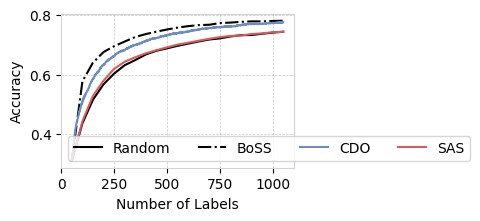

In [7]:
plt.figure(figsize=(3, 2))

strat_plot_kwargs = {
    'random':                     dict(c='black', ls='-',  lw=1.5, label="Random"),
    'perf_dal_oracle':            dict(c='black', ls='-.', lw=1.5, label="BoSS"),
    'cross_domain_oracle':        dict(c='C0',    ls='-',  lw=1.5, label="CDO"),
    'simulated_annealing_oracle': dict(c='C1',    ls='-',  lw=1.5, label="SAS"),
}
for key in acc_curves_strategies:
    plot_kw = strat_plot_kwargs[key]
    try:
        plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0), **plot_kw)
    except:
        plt.plot(axis_single, np.mean(acc_curves_strategies[key], axis=0), **plot_kw)

plt.xlabel('Number of Labels')
plt.ylabel('Accuracy')
plt.legend(ncol=5)
plt.savefig(plot_dir / f'lc_acc_{dataset}.pdf', bbox_inches='tight')

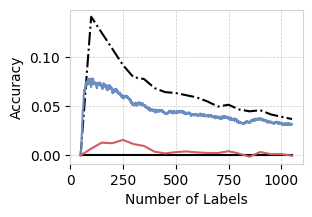

In [8]:
plt.figure(figsize=(3, 2))
acc_random = np.mean(acc_curves_random, axis=0)
strat_plot_kwargs = {
    'random':                     dict(c='black', ls='-',  lw=1.5),
    'perf_dal_oracle':            dict(c='black', ls='-.', lw=1.5),
    'cross_domain_oracle':        dict(c='C0',   ls='-',  lw=1.5),
    'simulated_annealing_oracle': dict(c='C1',  ls='-',  lw=1.5),
}
for key in acc_curves_strategies:
    plot_kw = strat_plot_kwargs[key]
    try:
        acc_improvment = np.mean(acc_curves_strategies[key], axis=0) - acc_random
        plt.plot(axis, acc_improvment, label=key, **plot_kw)
    except:
        acc_random_interp = np.interp(axis_single, axis, acc_random)
        acc_improvment = np.mean(acc_curves_strategies[key]- acc_random_interp, axis=0)
        plt.plot(axis_single, acc_improvment, label=key, **plot_kw)


plt.xlabel('Number of Labels')
plt.ylabel('Accuracy')
# plt.legend()
plt.savefig(plot_dir / f'lc_relacc_{dataset}.pdf')

In [10]:
np.mean(np.sum(times_per_strat['cross_domain_oracle'], axis=1))

np.float64(2648.180687403679)

## Influence of Strategies (NEW)

In [6]:
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/oracle.db'
dataset = "cifar10"
backbone = "dinov2"
runs = get_runs(uri, 'strategies_v2', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'"])
print(len(runs))

pick_matrices = []
for run in runs:
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)

    metric_names = [m for m in run.data.metrics if 'bought' in m]
    pick_matrix = [v.value for m in metric_names for v in client.get_metric_history(run.info.run_id, m)]
    pick_matrix = [[v.value for v in client.get_metric_history(run.info.run_id, m)] for m in metric_names ]
    pick_matrix = np.array(pick_matrix)
    pick_matrix = pick_matrix[:, 1:] - pick_matrix[:, :-1]
    pick_matrices.append(pick_matrix)

metric_names = [m.removeprefix('bought_') for m in metric_names]
picks = zip(metric_names, np.mean(pick_matrices, axis=(0, 2)).tolist())

for name, perc in sorted(picks, key=lambda x: -x[1]):
    print("{:15} | {:.2f}".format(name, perc*100))

10
dropquery       | 23.50
dropqueryclass  | 17.00
alfamix         | 12.50
baitsampling    | 9.50
randomsampling  | 7.50
typiclust       | 7.50
typiclass       | 7.50
coreset         | 7.50
marginsampling  | 4.50
badge           | 3.00


In [7]:
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/oracle.db'
dataset = "dopanim"
backbone = "dinov2"
runs = []
# runs.extend(get_runs(uri, 'oracle_comparison_v2', ["parameter.dataset_name = 'cifar10'", "al.strategy = 'random'"]),)
runs.extend(get_runs(uri, 'strategies_v2', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", "parameter.al.optimal.strategies = \"['random']\""]),)
runs.extend(get_runs(uri, 'strategies_v2', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", "parameter.al.optimal.strategies = \"['random', 'dropquery']\""]))
runs.extend(get_runs(uri, 'strategies_v2', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", "parameter.al.optimal.strategies = \"['random', 'dropquery', 'alfamix']\""]))
runs.extend(get_runs(uri, 'strategies_v2', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", "parameter.al.optimal.strategies = \"['random', 'dropquery', 'alfamix', 'typiclust']\""]))
runs.extend(get_runs(uri, 'strategies_v2', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", "parameter.al.optimal.strategies = \"['random', 'dropquery', 'alfamix', 'typiclust', 'bait']\""]))
runs.extend(get_runs(uri, 'strategies_v2', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", "parameter.al.optimal.strategies = \"['random', 'dropquery', 'alfamix', 'typiclust', 'bait', 'coreset']\""]))
runs.extend(get_runs(uri, 'strategies_v2', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", "parameter.al.optimal.strategies = \"['random', 'dropquery', 'alfamix', 'typiclust', 'bait', 'coreset', 'margin']\""]))
runs.extend(get_runs(uri, 'strategies_v2', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", "parameter.al.optimal.strategies = \"['random', 'dropquery', 'alfamix', 'typiclust', 'bait', 'coreset', 'margin', 'badge']\""]))

acq_size = int(runs[0].data.params['al.acq_size'])
num_acq = int(runs[0].data.params['al.num_acq'])
axis = np.arange(acq_size, (acq_size*(num_acq+1))+1, acq_size)

acc_curves_strategies = defaultdict(list)
for run in runs:
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)
    key = run.data.params['al.optimal.strategies']
    acc_curves_strategies[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

for key in acc_curves_strategies:
    print("{:40} {:4}".format(key, len(acc_curves_strategies[key])))

['random']                                 10
['random', 'dropquery']                    10
['random', 'dropquery', 'alfamix']         10
['random', 'dropquery', 'alfamix', 'typiclust']   10
['random', 'dropquery', 'alfamix', 'typiclust', 'bait']   10
['random', 'dropquery', 'alfamix', 'typiclust', 'bait', 'coreset']   10
['random', 'dropquery', 'alfamix', 'typiclust', 'bait', 'coreset', 'margin']   10
['random', 'dropquery', 'alfamix', 'typiclust', 'bait', 'coreset', 'margin', 'badge']   10


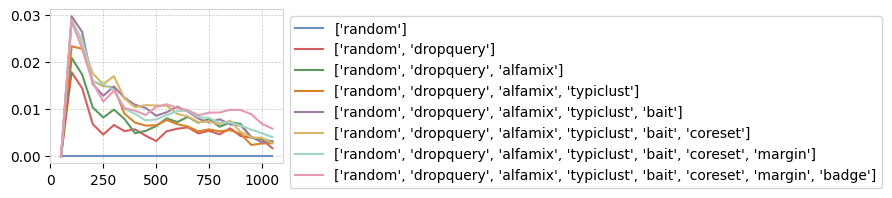

In [8]:
plt.figure(figsize=(3, 2))
for key in acc_curves_strategies:
    plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0) - np.mean(acc_curves_strategies["['random']"], axis=0), label=key, lw=1.5)
# plt.tight_layout()

plt.legend(bbox_to_anchor=(1, 1))

In [10]:
strategies = [
    "\"['random']\"",
    "\"['random', 'dropquery']\"",
    "\"['random', 'dropquery', 'alfamix']\"",
    "\"['random', 'dropquery', 'alfamix', 'typiclust']\"",
    "\"['random', 'dropquery', 'alfamix', 'typiclust', 'bait']\"",
    "\"['random', 'dropquery', 'alfamix', 'typiclust', 'bait', 'coreset']\"",
    "\"['random', 'dropquery', 'alfamix', 'typiclust', 'bait', 'coreset', 'margin']\"",
    "\"['random', 'dropquery', 'alfamix', 'typiclust', 'bait', 'coreset', 'margin', 'badge']\"",
    "\"['random', 'dropquery', 'alfamix', 'typiclust', 'bait', 'coreset', 'margin', 'badge', 'dropqueryclass']\"",
    "\"['random', 'dropquery', 'alfamix', 'typiclust', 'bait', 'coreset', 'margin', 'badge', 'dropqueryclass', 'typiclass']\"",
    ]

backbones = ["dinov2", "swinv2"]
# backbone = backbones[1]

data = np.zeros((1, len(strategies)))
data_std = np.zeros((1, len(strategies)))


for i_strat, strategy in enumerate(strategies):
    runs = get_runs(uri, 'strategies_v2', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", f"parameter.al.optimal.strategies = {strategy}"])

    accuracies = [[m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')] for run in runs]
    lc_mean = np.mean(accuracies, axis=0)
    lc_std = np.std(accuracies, axis=0)

    auc = lc_mean.mean()
    data[0, i_strat] = auc
    data_std[0, i_strat] = lc_std.mean() / np.sqrt(10)

import pandas as pd
strategies = ['Random', '+DropQuery', '+AlfaMix', '+TypiClust', '+Bait', '+CoreSet', '+Margin', '+Badge', '+DropQuery*', '+TypiClust*']
datasets = ['Dopanim', 'CIFAR-100', 'Food101', 'Tiny ImageNet', 'Dopanim', 'CIFAR-100', 'Food101', 'Tiny ImageNet']
df = pd.DataFrame(data, columns=strategies).T
df_std = pd.DataFrame(data_std, columns=strategies).T

df_combined = df.multiply(100).round(2).astype(str).add('\\textsubscript{$\pm$').add(df_std.multiply(100).round(2).astype(str).add('}'))
print(df_combined.to_latex())

\begin{tabular}{ll}
\toprule
 & 0 \\
\midrule
Random & 75.24\textsubscript{$\pm$0.15} \\
+DropQuery & 75.82\textsubscript{$\pm$0.17} \\
+AlfaMix & 76.01\textsubscript{$\pm$0.16} \\
+TypiClust & 76.08\textsubscript{$\pm$0.17} \\
+Bait & 76.28\textsubscript{$\pm$0.16} \\
+CoreSet & 76.29\textsubscript{$\pm$0.2} \\
+Margin & 76.26\textsubscript{$\pm$0.18} \\
+Badge & 76.35\textsubscript{$\pm$0.18} \\
+DropQuery* & 76.41\textsubscript{$\pm$0.18} \\
+TypiClust* & 76.52\textsubscript{$\pm$0.18} \\
\bottomrule
\end{tabular}



## Influence of Strategies

In [7]:
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/oracle.db'
runs = []
dataset = ["cifar10", "dopanim", "cifar100", "food101", "tiny_imagenet"][4]
backbone = ["dinov2", "swinv2"][1]
# runs.extend(get_runs(uri, 'oracle_comparison_v2', ["parameter.dataset_name = 'cifar10'", "al.strategy = 'random'"]),)
runs.extend(get_runs(uri, 'strategies_v1', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", "parameter.al.optimal.strategies = \"['random']\""]),)
runs.extend(get_runs(uri, 'strategies_v1', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", "parameter.al.optimal.strategies = \"['random', 'dropquery']\""]))
runs.extend(get_runs(uri, 'strategies_v1', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", "parameter.al.optimal.strategies = \"['random', 'dropquery', 'bait']\""]))
runs.extend(get_runs(uri, 'strategies_v1', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", "parameter.al.optimal.strategies = \"['random', 'dropquery', 'bait', 'typiclust']\""]))
runs.extend(get_runs(uri, 'strategies_v1', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", "parameter.al.optimal.strategies = \"['random', 'dropquery', 'bait', 'typiclust', 'alfamix']\""]))

acq_size = int(runs[0].data.params['al.acq_size'])
num_acq = int(runs[0].data.params['al.num_acq'])
axis = np.arange(acq_size, (acq_size*(num_acq+1))+1, acq_size)

acc_curves_strategies = defaultdict(list)
for run in runs:
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)
    key = run.data.params['al.optimal.strategies']
    acc_curves_strategies[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

for key in acc_curves_strategies:
    print("{:40} {:4}".format(key, len(acc_curves_strategies[key])))

['random']                                 10
['random', 'dropquery']                    10
['random', 'dropquery', 'bait']            10
['random', 'dropquery', 'bait', 'typiclust']   10
['random', 'dropquery', 'bait', 'typiclust', 'alfamix']   10


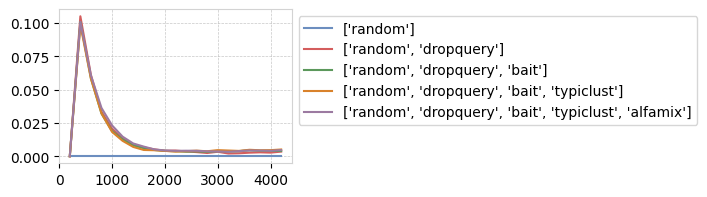

In [8]:
plt.figure(figsize=(3, 2))
for key in acc_curves_strategies:
    plt.plot(axis, np.mean(acc_curves_strategies[key], axis=0) - np.mean(acc_curves_strategies["['random']"], axis=0), label=key, lw=1.5)
# plt.tight_layout()

plt.legend(bbox_to_anchor=(1, 1))

In [9]:
datasets = ["dopanim", "cifar100", "food101", "tiny_imagenet"]
strategies = [
    "\"['random']\"", 
    "\"['random', 'dropquery']\"", 
    "\"['random', 'dropquery', 'bait']\"", 
    "\"['random', 'dropquery', 'bait', 'typiclust']\"",
    "\"['random', 'dropquery', 'bait', 'typiclust', 'alfamix']\"",
    ]

backbones = ["dinov2", "swinv2"]
# backbone = backbones[1]

data = np.zeros((len(datasets)*len(backbones), len(strategies)))
data_std = np.zeros((len(datasets)*len(backbones), len(strategies)))


for i_bb, backbone in enumerate(backbones):
    for i_ds, dataset in enumerate(datasets):
        i_ds = i_bb*len(datasets) + i_ds
        for i_strat, strategy in enumerate(strategies):
            runs = get_runs(uri, 'strategies_v1', [f"parameter.dataset_name = '{dataset}'", f"parameter.backbone = '{backbone}'", f"parameter.al.optimal.strategies = {strategy}"])

            accuracies = [[m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')] for run in runs]
            lc_mean = np.mean(accuracies, axis=0)
            lc_std = np.std(accuracies, axis=0)

            auc = lc_mean.mean()
            data[i_ds, i_strat] = auc
            data_std[i_ds, i_strat] = lc_std.mean() / 10



No runs found with query list ["parameter.dataset_name = 'dopanim'", "parameter.backbone = 'swinv2'", 'parameter.al.optimal.strategies = "[\'random\', \'dropquery\']"'].
No runs found with query list ["parameter.dataset_name = 'dopanim'", "parameter.backbone = 'swinv2'", 'parameter.al.optimal.strategies = "[\'random\', \'dropquery\', \'bait\']"'].
No runs found with query list ["parameter.dataset_name = 'dopanim'", "parameter.backbone = 'swinv2'", 'parameter.al.optimal.strategies = "[\'random\', \'dropquery\', \'bait\', \'typiclust\']"'].
No runs found with query list ["parameter.dataset_name = 'dopanim'", "parameter.backbone = 'swinv2'", 'parameter.al.optimal.strategies = "[\'random\', \'dropquery\', \'bait\', \'typiclust\', \'alfamix\']"'].


/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rco

In [10]:
import pandas as pd
strategies = ['Random', '+DropQuery', '+Bait', '+TypiClust', '+AlfaMix']
datasets = ['Dopanim', 'CIFAR-100', 'Food101', 'Tiny ImageNet', 'Dopanim', 'CIFAR-100', 'Food101', 'Tiny ImageNet']
df = pd.DataFrame(data, columns=strategies, index=datasets).T
df_std = pd.DataFrame(data_std, columns=strategies, index=datasets).T

df_combined = df.multiply(100).round(2).astype(str).add('\\textsubscript{$\pm$').add(df_std.multiply(100).round(2).astype(str).add('}'))
print(df_combined.to_latex())

\begin{tabular}{lllllllll}
\toprule
 & Dopanim & CIFAR-100 & Food101 & Tiny ImageNet & Dopanim & CIFAR-100 & Food101 & Tiny ImageNet \\
\midrule
Random & 75.35\textsubscript{$\pm$0.05} & 69.82\textsubscript{$\pm$0.04} & 70.77\textsubscript{$\pm$0.04} & 65.48\textsubscript{$\pm$0.03} & 70.77\textsubscript{$\pm$0.0} & 65.45\textsubscript{$\pm$0.05} & 51.18\textsubscript{$\pm$0.05} & 74.81\textsubscript{$\pm$0.04} \\
+DropQuery & 75.93\textsubscript{$\pm$0.06} & 71.42\textsubscript{$\pm$0.03} & 72.46\textsubscript{$\pm$0.04} & 67.17\textsubscript{$\pm$0.04} & nan\textsubscript{$\pm$nan} & 67.22\textsubscript{$\pm$0.04} & 52.34\textsubscript{$\pm$0.05} & 76.2\textsubscript{$\pm$0.03} \\
+Bait & 76.33\textsubscript{$\pm$0.06} & 72.81\textsubscript{$\pm$0.04} & 73.35\textsubscript{$\pm$0.04} & 68.32\textsubscript{$\pm$0.03} & nan\textsubscript{$\pm$nan} & 67.33\textsubscript{$\pm$0.05} & 51.87\textsubscript{$\pm$0.05} & 76.18\textsubscript{$\pm$0.03} \\
+TypiClust & 76.25\textsubscript{$\pm$

# Consider a single experiment

In [ ]:
seed = 1
print(runs_per_strat.keys())
strat = 'perf_dal_oracle'
run = runs_per_strat[strat][0]
artifact_path = download_artifacts(run)

with open(artifact_path / f'artifacts_cycle20', "r") as f:
    results_acq_si = json.load(f)


dict_keys(['random', 'perf_dal_oracle', 'cross_domain_oracle'])
receiving incremental file list

sent 20 bytes  received 365 bytes  256.67 bytes/sec
total size is 1,367,339  speedup is 3,551.53


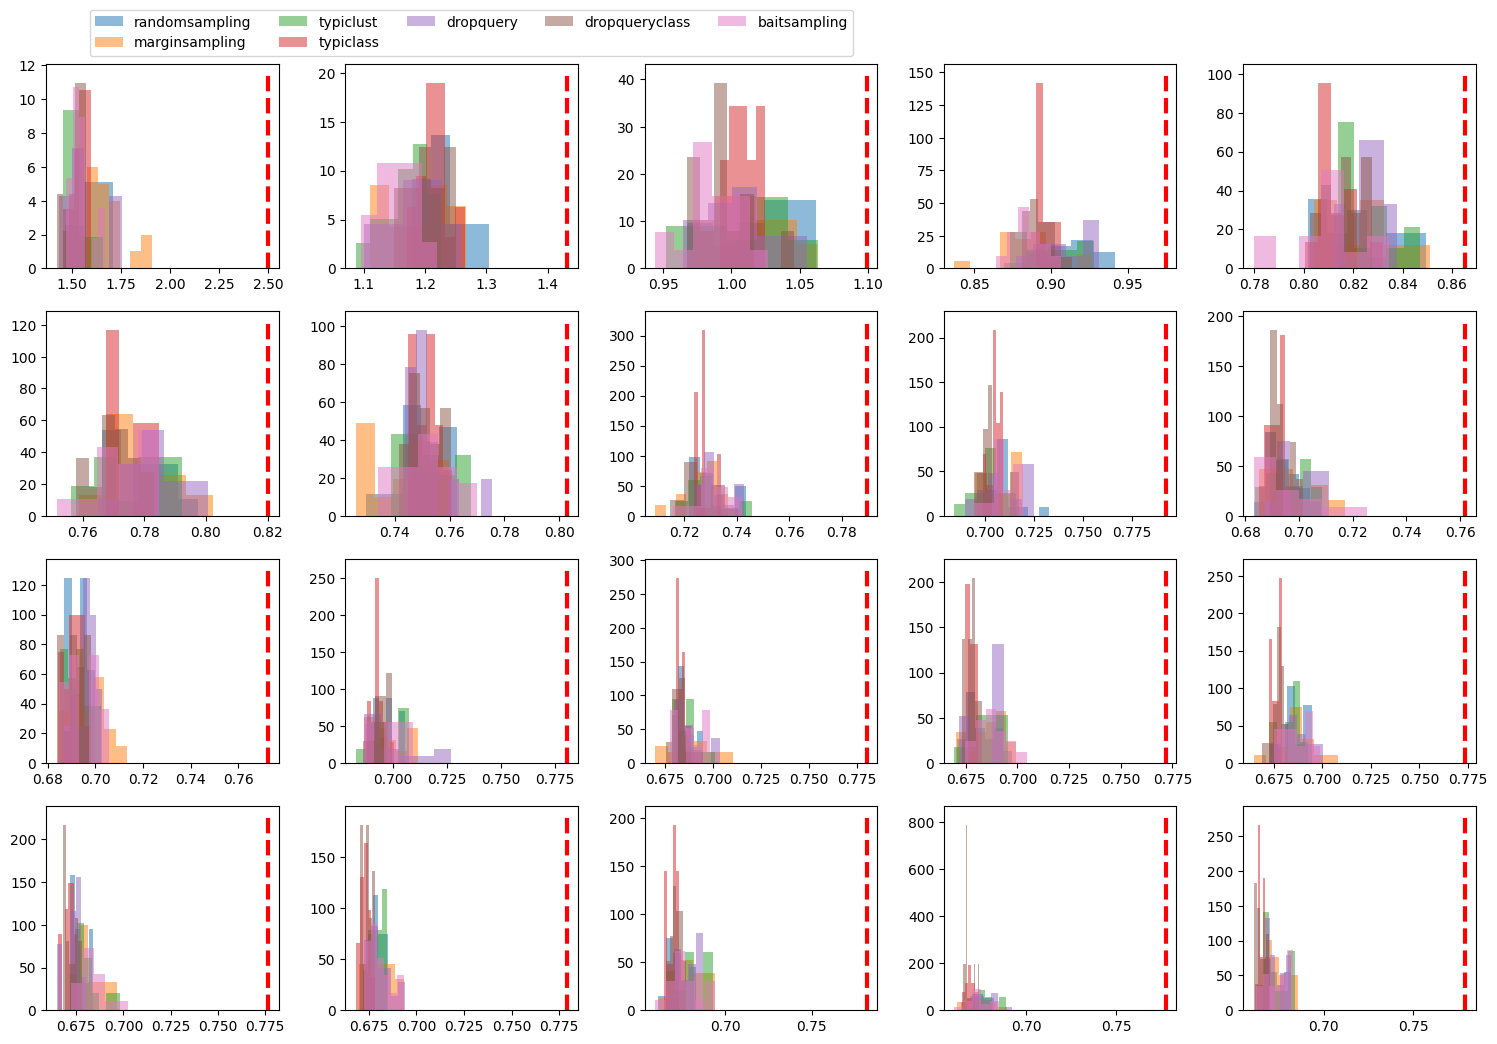

In [ ]:
from copy import deepcopy
oracle_history = results_acq_si['oracle_history']
fig, axes = plt.subplots(4, 5, figsize=(15, 10))
axes = axes.flatten()
for i_cycle, d in enumerate(oracle_history):
    loss_batches = d['loss_batches']
    base_loss = d['base_loss']
    batches_counts = deepcopy(d['batches_counts'])

    # del batches_counts['random']
    # del batches_counts['diverse']
    # del batches_counts['uncertain']

    plt.sca(axes[i_cycle])
    losses_per_type = np.split(loss_batches, np.cumsum(list(batches_counts.values())[:-1]))
    for losses, type in zip(losses_per_type, batches_counts):
        plt.hist(losses, bins='auto', density=True, label=type, alpha=0.5)
    plt.vlines(base_loss, *plt.ylim(), colors='red', lw=3, ls='--')
plt.tight_layout()
axes[0].legend(loc=1, bbox_to_anchor=(3.5, 1.3), ncols=5)

In [ ]:
import torch
import sys
import argparse
sys.path.append('..')
from utils import build_image_data
from dal_toolbox.utils import seed_everything
from torchvision.utils import make_grid

query_indices_dict = {}
model_weights_dict = {}
artifact_paths = sorted(list(artifact_path.glob('*')), key=lambda x: int(x.stem.lstrip('artifacts_cycle')))
for i_acq, a_path in enumerate(artifact_paths):
    with open(a_path, "r") as f:
        results_acq_si = json.load(f)
    results_acq_si['query_indices'] = [int(idx) for idx in results_acq_si['query_indices']]
    query_indices_dict[i_acq] = results_acq_si['query_indices']
    model_weights_dict[i_acq] = results_acq_si['model']

args = argparse.Namespace(dataset_name=run.data.params['dataset_name'], dataset_path='/home/datasets')
seed_everything(42)
ds = build_image_data(args, plain_transforms=True)
query_ds = ds.train_dataset
query_indices = np.concat([query_indices_dict[i_acq] for i_acq in query_indices_dict])

/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'artifact_path' is not defined

In [73]:
from torch.utils.data import DataLoader
from dal_toolbox.datasets.utils import DinoTransforms
from dal_toolbox.utils import seed_everything
device ='cuda'

seed_everything(42)
tsne_indices = torch.arange(len(query_ds))
# tsne_indices = torch.randperm(len(query_ds))[:1000]
# tsne_indices = torch.cat((tsne_indices, torch.tensor(query_indices))).unique()

query_ds.dataset.transform = DinoTransforms(size=(256, 256)).transform
dl = DataLoader(query_ds, sampler=tsne_indices, batch_size=128, num_workers=8)
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')

features = []
labels = []
model.eval()
model.to(device)
for batch in dl:
    features.append(model(batch[0].to(device)).to('cpu'))
    labels.append(batch[-1])
features = torch.cat(features)
labels = torch.cat(labels)

Seed set to 42
Using cache found in /home/dhuseljic/.cache/torch/hub/facebookresearch_dinov2_main


In [74]:
from sklearn.manifold import TSNE

tsne = TSNE(random_state=42)
features_tsne = tsne.fit_transform(features)


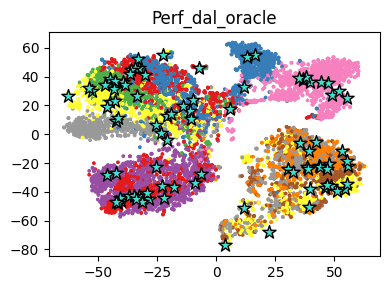

In [ ]:
plt.title(strat.capitalize())
plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=labels, s=3, cmap='Set1')
plt.scatter(features_tsne[query_indices[10:100], 0], features_tsne[query_indices[10:100], 1], c='turquoise', s=100, marker='*', lw=1, ec='k')
plt.tight_layout()
# plt.savefig(f'plots/{dataset}_tsne_{strat}.pdf', bbox_inches='tight')

array([ 3, 11, 12])

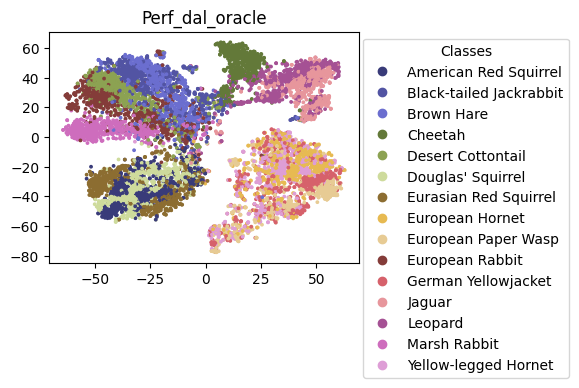

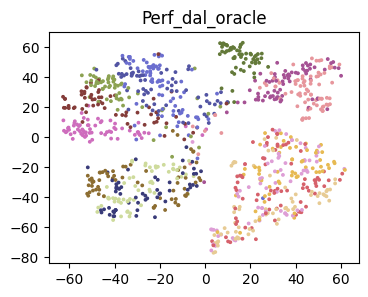

In [136]:
plt.figure()
plt.title(strat.capitalize())
scatter = plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=labels, s=3, cmap='tab20b')

handles, _ = scatter.legend_elements(num=14)
unique_numeric_labels = np.unique(labels)
string_labels = query_ds.dataset.le.inverse_transform(unique_numeric_labels)
plt.legend(handles, string_labels, title="Classes", loc=1, bbox_to_anchor=(1.7, 1))
xlim = plt.xlim()
ylim = plt.ylim()
# plt.savefig(f'plots/{dataset}_tsne_{strat}.pdf', bbox_inches='tight')

idx = np.random.permutation(len(features_tsne))[:1000]
plt.figure()
plt.title(strat.capitalize())
scatter = plt.scatter(features_tsne[idx, 0], features_tsne[idx, 1], c=labels[idx], s=3, cmap='tab20b')

## Time Experiments

In [2]:
uri = 'sqlite:////home/dhuseljic/oracle_times.db'
exp = 'oracle_time'

experiments = {
    'cifar10': {
        'cross_domain_oracle': lambda: get_runs(uri, exp, ["parameter.dataset_name = 'cifar10'", "parameter.al.strategy = 'cross_domain_oracle'"]),
        'perf_dal_oracle': lambda: get_runs(uri, exp, ["parameter.dataset_name = 'cifar10'", "parameter.al.strategy = 'perf_dal_oracle'"]),
    },
    'dtd': { # TODO
        'cross_domain_oracle': lambda: get_runs(uri, exp, ["parameter.dataset_name = 'dtd'", "parameter.al.strategy = 'cross_domain_oracle'"]),
        'perf_dal_oracle': lambda: get_runs(uri, exp, ["parameter.dataset_name = 'dtd'", "parameter.al.strategy = 'perf_dal_oracle'"]),
    },
    'cifar100': { # TODO
        'cross_domain_oracle': lambda: get_runs(uri, exp, ["parameter.dataset_name = 'cifar100'", "parameter.al.strategy = 'cross_domain_oracle'"]),
        'perf_dal_oracle': lambda: get_runs(uri, exp, ["parameter.dataset_name = 'cifar100'", "parameter.al.strategy = 'perf_dal_oracle'"]),
    },
}

<BarContainer object of 2 artists>

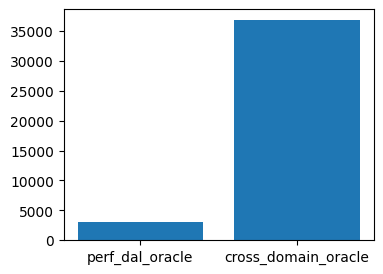

In [ ]:
ds = 'cifar100'
times = dict()
run = experiments[ds]['perf_dal_oracle']()[0]
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
key = run.data.params['al.strategy']
times[key] = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

run = experiments[ds]['cross_domain_oracle']()[0]
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
key = run.data.params['al.strategy']
times[key] = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
plt.bar(range(len(times)), [np.sum(v) for k, v in times.items()], tick_label=[k for k in times])

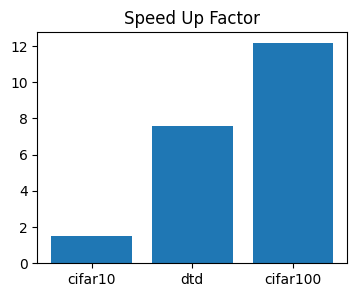

In [8]:
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
ds = 'cifar100'

speed_up_factors = dict()
for ds in ['cifar10', 'dtd', 'cifar100']:
    run = experiments[ds]['perf_dal_oracle']()[0]
    key = run.data.params['al.strategy']
    times_perf = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

    run = experiments[ds]['cross_domain_oracle']()[0]
    key = run.data.params['al.strategy']
    times_cross = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

    speed_up_factors[ds] = np.sum(times_cross) / np.sum(times_perf)

plt.title('Speed Up Factor')
plt.bar(range(len(speed_up_factors)), [np.sum(v) for k, v in speed_up_factors.items()], tick_label=[k for k in speed_up_factors])
plt.show()

array(['Leopard', 'Marsh Rabbit', 'Brown Hare', ...,
       'Black-tailed Jackrabbit', 'Leopard', 'Marsh Rabbit'], dtype=object)